In [56]:
# Manage Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [71]:
# load data
df = pd.read_csv('coffeeFilterData.txt', sep='\t', skiprows=2)
# adjust time
df['time(s)'] = df['time(s)'] - df['time(s)'].min()
# drop whitespace
df.dropna(inplace=True)

# seperate columns into two arrays
t_data = df["time(s)"].values
y_data = df["y(m)(6filt)"].values

In [72]:
# constants
m = 5.3e-3  # kg
g = 9.81    # m/s^2
y0 = y_data[0]

# models
def const_accel(t):
    return y0 - 0.5 * g * t**2

def yf(t, k):
    vt = np.sqrt(m * g / k)
    return y0 - (vt**2 / g) * np.log(np.cosh(g * t / vt))

In [ ]:
# fit 
popt, pcov = curve_fit(yf, t_data, y_data, p0=[0.046])
k_fit = popt[0]

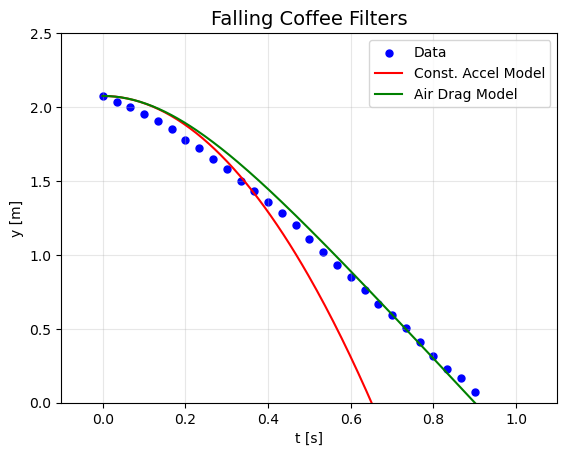

In [75]:

# plot
ta = np.linspace(0.0, 1.0, 200)

plt.scatter(t_data, y_data, color='b', s=25, label='Data')
plt.plot(ta, const_accel(ta), 'r-', label='Const. Accel Model')
plt.plot(ta, yf(ta, k_fit), 'g-',
         label="Air Drag Model")
plt.xlabel('t [s]')
plt.ylabel('y [m]')
plt.title("Falling Coffee Filters", fontsize=14)
plt.ylim(0, 2.5)
plt.xlim(-0.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('coffeeFilterFit.png', dpi=300)
plt.show()